<a href="https://colab.research.google.com/github/vishalrathod7453/-IPL-2025-Analysis/blob/main/Datascience_B_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Panadas**

Panadas for data scinnce

In [ ]:
import pandas as pd
import numpy as np



In [ ]:
a = [10,20,30,40,50]

b =['vishal','ram','pavan','vijay','aniket']

Se =pd.Series(b)
Se

,0
0,vishal
1,ram
2,pavan
3,vijay
4,aniket


In [ ]:
df=pd.DataFrame({
  'sr_no' :['1','2','3','4','5','6'],
  'name' :['vishal','ram','pavan','vijay','aniket','unknown'],
  'city' :['pune','nanded','sambhajinagar','jalna','unknown_city1','unknown_city2']
})
df

,sr_no,name,city
0,1,vishal,pune
1,2,ram,nanded
2,3,pavan,sambhajinagar
3,4,vijay,jalna
4,5,aniket,unknown_city1
5,6,unknown,unknown_city2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sr_no   6 non-null      object
 1   name    6 non-null      object
 2   city    6 non-null      object
dtypes: object(3)
memory usage: 276.0+ bytes


In [ ]:
df.dtypes

,0
sr_no,object
name,object
city,object


In [ ]:
df.index

RangeIndex(start=0, stop=6, step=1)

In [ ]:
df.head(3)

,sr_no,name,city
0,1,vishal,pune
1,2,ram,nanded
2,3,pavan,sambhajinagar


In [ ]:
df.tail(2)

,sr_no,name,city
4,5,aniket,unknown_city1
5,6,unknown,unknown_city2


In [ ]:
df.describe()

,sr_no,name,city
count,6,6,6
unique,6,6,6
top,1,vishal,pune
freq,1,1,1


In [ ]:
df.shape

(6, 3)

**Data cleaning**

In [ ]:
vr=pd.read_csv('/content/ambitionbox_scraped 2.csv')
vr

,campany,ratings,reviews,sector,location,years,employess,salary
0,TCS,4.0,(22.1k Reviews),Public,"Mumbai,Maharashtra + 190 more",53 years old,100001+ employees,247.6k
1,Accenture,4.0,(18.4k Reviews),Public,"Dublin,Dublin + 112 more",32 years old,100001+ employees,175.2k
2,ICICI Bank,4.0,(16.8k Reviews),Public,Mumbai + 831 more,27 years old,50001-100000 employees,74.1k
3,Cognizant,3.8,(16.4k Reviews),Private,Teaneck + 59 more,27 years old,100001+ employees,190.2k
4,HDFC Bank,4.0,(14.7k Reviews),Public,"Mumbai,Maharashtra + 877 more",27 years old,100001+ employees,69.6k
...,...,...,...,...,...,...,...,...
9955,Time Inc.,4.0,(34 Reviews),Private,"New York,New York State + 1 more",99 years old,5001-10000 employees,150
9956,Nims Hospital,4.3,(34 Reviews),Private,Thiruvananthapuram + 6 more,16 years old,1001-5000 employees,107
9957,Saggraha Managemen...,4.3,(34 Reviews),Bengaluru + 7 more,7 years old,501-1000 employees,NaN,134
9958,DB Engineering & C...,4.2,(34 Reviews),Berlin + 4 more,55 years old,1001-5000 employees,NaN,142


In [ ]:
vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9960 entries, 0 to 9959
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   campany    9960 non-null   object 
 1   ratings    9960 non-null   float64
 2   reviews    9960 non-null   object 
 3   sector     9950 non-null   object 
 4   location   9834 non-null   object 
 5   years      9387 non-null   object 
 6   employess  7338 non-null   object 
 7   salary     9959 non-null   object 
dtypes: float64(1), object(7)
memory usage: 622.6+ KB


In [ ]:
vr.shape

(9960, 8)

In [ ]:
vr.head()

,campany,ratings,reviews,sector,location,years,employess,salary
0,TCS,4.0,(22.1k Reviews),Public,"Mumbai,Maharashtra + 190 more",53 years old,100001+ employees,247.6k
1,Accenture,4.0,(18.4k Reviews),Public,"Dublin,Dublin + 112 more",32 years old,100001+ employees,175.2k
2,ICICI Bank,4.0,(16.8k Reviews),Public,Mumbai + 831 more,27 years old,50001-100000 employees,74.1k
3,Cognizant,3.8,(16.4k Reviews),Private,Teaneck + 59 more,27 years old,100001+ employees,190.2k
4,HDFC Bank,4.0,(14.7k Reviews),Public,"Mumbai,Maharashtra + 877 more",27 years old,100001+ employees,69.6k


In [ ]:
vr.describe()

,ratings
count,9960.00000
mean,3.86761
std,0.43076
min,1.60000
25%,3.60000
50%,3.90000
75%,4.20000
max,5.00000


In [ ]:
vr.isnull().sum()

,0
campany,0
ratings,0
reviews,0
sector,0
location,0
years,0
employess,0
salary,0
salary_cleaned,0


In [ ]:
vr.isnull().sum()

In [ ]:
vr.dropna().sum()

In [ ]:
vr['campany']

,campany
0,TCS
1,Accenture
2,ICICI Bank
3,Cognizant
4,HDFC Bank
...,...
9951,The Fern An Ecotel...
9952,Tamil Nadu State T...
9954,G.R. Engineering
9955,Time Inc.


In [ ]:
vr.[['salary','campany']]

In [ ]:
def clean_salary(salary_str):
    if isinstance(salary_str, str):
        salary_str = salary_str.replace(',', '').strip()
        if 'k' in salary_str.lower():
            return float(salary_str.lower().replace('k', '')) * 1000
        try:
            return float(salary_str)
        except ValueError:
            return None
    return salary_str

vr['salary_cleaned'] = vr['salary'].apply(clean_salary)
vr['salary_cleaned'] = pd.to_numeric(vr['salary_cleaned'], errors='coerce')
print(vr['salary_cleaned'].mean())

837.5406165277639


In [ ]:
vr['ratings'].max()
vr['ratings'].mean()

np.float64(3.867610441767068)

Data cl

In [ ]:
vr['sector'] = vr['sector'].fillna('Other')

In [ ]:
vr =vr.dropna()

In [ ]:
vr=vr.dropna(inplace=True)

In [ ]:
vs=pd.read_csv('/content/Employee dataset.csv')
vs

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [ ]:
vs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [ ]:
vs.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [ ]:
vs.shape

(4653, 9)

In [ ]:
vs.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [ ]:
vs.duplicated().sum()

np.int64(1889)

In [ ]:
vs.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4645,False
4647,False
4649,False
4650,False


In [ ]:
vs[vs.duplicated]

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot


In [ ]:
vs =vs.drop_duplicates()

In [ ]:
vs =vs.dropna()
vs

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4645,Masters,2017,Pune,2,31,Female,No,2,0
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1


In [ ]:
vs.dropna(inplace=True)

In [ ]:
vs.isnull().sum()

In [ ]:
vs['Age'].max()

41

In [ ]:
vs.rename(columns={'JoiningYear': 'Joining_years'}, inplace=True)


In [ ]:
vs.to_csv('Clean_data.csv',index=False)

AttributeError: 'NoneType' object has no attribute 'to_csv'

Specific Colum Removes

vs=vs.drop(colum=['LeaveOrNot'])

1.find colums = . df.dubicates().sum()
                
                * df.[dubicates]

2.Remove Dubicates = df.dropdubicates()

3. rename colum = df.rename(colum=['old':new colum])
4. remove particular colum = df.dropna(colum=['col]

5.find null recordes = df.isnull().sum()

6. remove null= df.dfropna()

7. fill null values =df.fillna()

8 .Sorting the recordes = df.sort()

9 . download Cleaning Data

  df.to_csv('Clean_data.csv',index=False)

In [ ]:
vs.Sort_values['Age']

AttributeError: 'NoneType' object has no attribute 'Sort_values'

In [ ]:
so

In [ ]:
vs.

In [ ]:
import pandas as pd
import numpy as n dkp



In [ ]:
st=pd.read_csv('/content/StudentsPerformance.csv')
st

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
st.shape

(1000, 8)

In [ ]:
st.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
st.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [ ]:
st.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
st.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
st.duplicated().sum()

np.int64(0)

In [ ]:
st.drop_duplicates()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.dropna()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.sort_index()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.fillna('Other')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.rename(columns={'math score': 'math_score'}, inplace=True)

In [ ]:
st.dropna()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math_score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math_score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.shape

(1000, 8)

In [ ]:
st

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math_score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
st.groupby('math_score')['reading score'].min()

,reading score
math_score,
0,17
8,24
18,32
19,38
22,39
...,...
96,90
97,82
98,86


20 February
# *  Marge Data. (Marge data aplly on both same table in colum)

Syntax

pd.marge(df1.df2, on ='Student_ID',how = inner')
data.head()


# * Groupby Function

syntax

data.groupby (['colum_name'.'colum 2])[apply on integer colum].min()






In [ ]:
from typing import dataclass_transform
Marge dataclass_transform


# Matplotlib Library for data Science
1. line chart
2. bar chart
3. Scaterchart
4. histogram chart
4. pie chart
5. Box chart
6. violine chart
7. Barh Chart

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vr =pd.read_csv('/content/ipl_batsman.csv')
vr

,match_id,date,player_team,striker,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,doubles,triples,fours,fives,sixes,dismissal_type
0,202501,2025-03-22,KKR,de Kock,1,5,4,80.000000,4,0,0,0,1,0,0,caught
1,202501,2025-03-22,KKR,Rahane,2,31,56,180.645161,14,6,1,0,6,0,4,caught
2,202501,2025-03-22,KKR,Narine,3,26,44,169.230769,13,4,1,0,5,0,3,caught
3,202501,2025-03-22,KKR,Venkatesh Iyer,4,7,6,85.714286,4,2,0,0,1,0,0,bowled
4,202501,2025-03-22,KKR,Angkrish Raghuvanshi,5,22,30,136.363636,4,14,1,0,2,0,1,caught
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,202574,2025-06-03,PBKS,Nehal Wadhera,5,18,15,83.333333,9,7,1,0,0,0,1,caught
1123,202574,2025-06-03,PBKS,Shashank Singh,6,30,61,203.333333,10,9,2,0,3,0,6,not out
1124,202574,2025-06-03,PBKS,Stoinis,7,2,6,300.000000,1,0,0,0,0,0,1,caught
1125,202574,2025-06-03,PBKS,Azmatullah,8,2,1,50.000000,1,1,0,0,0,0,0,caught


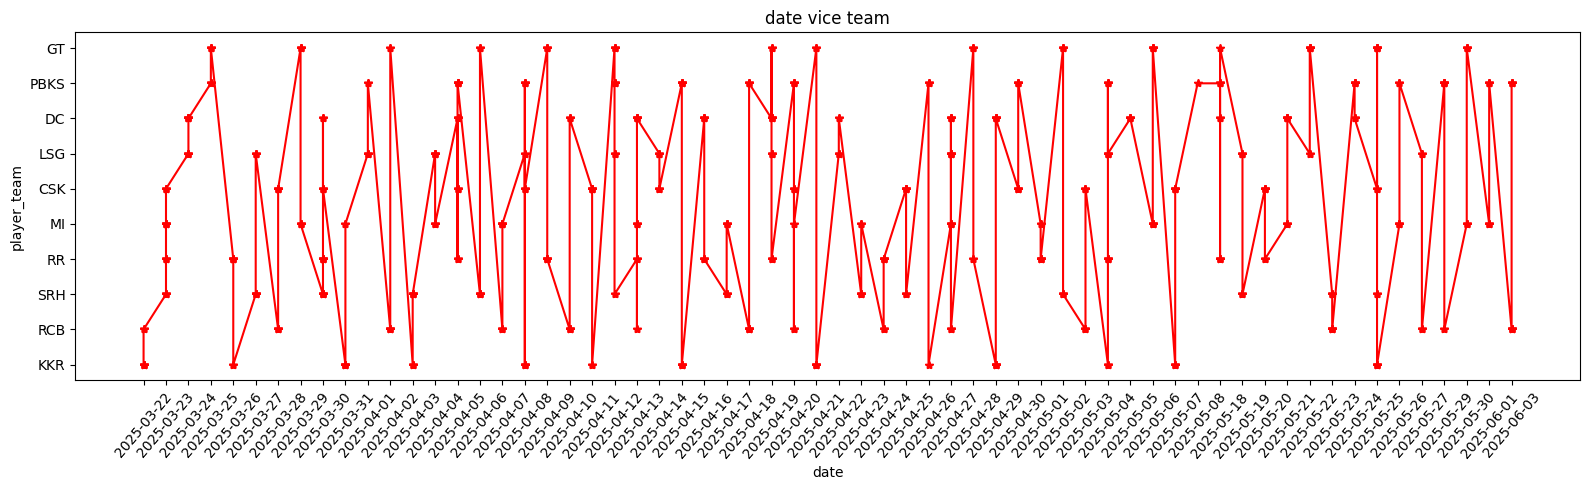

In [ ]:
plt.figure(figsize=(16,5))
plt.plot(vr['date'],vr['player_team'], marker = '*', color='red')
plt.xlabel('date')
plt.ylabel('player_team')
plt.xticks(rotation=50)
plt.title('date vice team')
plt.tight_layout()

plt.show()

In [ ]:
vr.shape

(1127, 16)

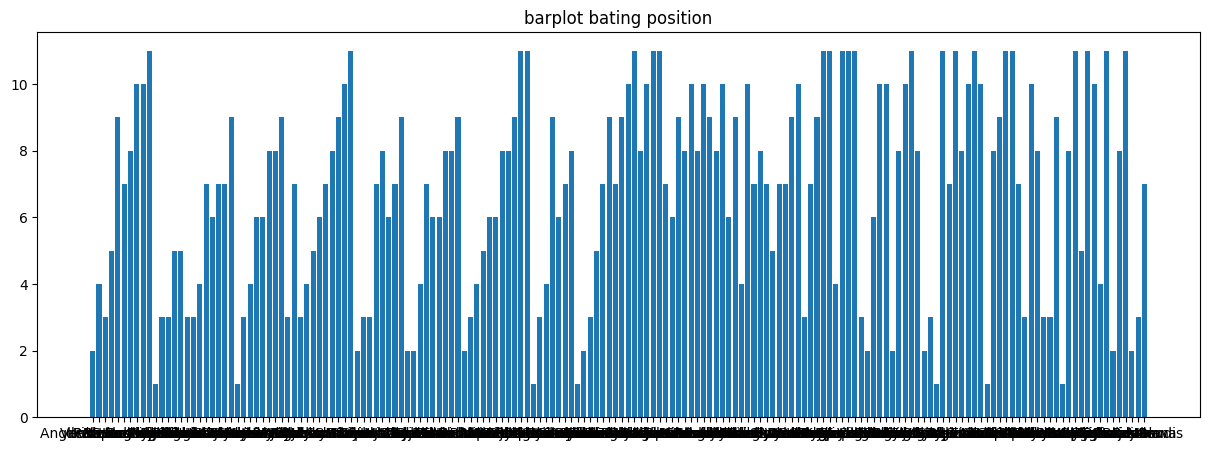

In [ ]:
plt.figure(figsize=(15,5))
plt.bar(vr['striker'],vr['batting_position'])
plt.title('barplot bating position')

plt.show()

In [ ]:
from os import path
data =pd.read_csv(f'{university/electoral-integrity}/')
print('Firs 5 records:',df.head())

NameError: name 'university' is not defined

In [ ]:
Print("First 5 records:", df.head())

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# The Kaggle dataset is mounted at this path
kaggle_dataset_path = '/kaggle/input/student-exam-performance-dataset-analysis'

# The correct filename identified from previous output
dataset_filename = "StudentPerformanceFactors.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "grandmaster07/student-exam-performance-dataset-analysis",
  dataset_filename
)

print("First 5 records:", df.head())

/tmp/ipython-input-3777980587.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.
First 5 records:    Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6            

In [ ]:
f = pd.read_csv('/ = pd.read_csv('/content/StudentsPerformance.csv')
print("First 5 records:", df.head())')


In [ ]:
vv=pd.read_csv('/content/SuperStoreOrders.csv')
vv

FileNotFoundError: [Errno 2] No such file or directory: '/content/SuperStoreOrders.csv'

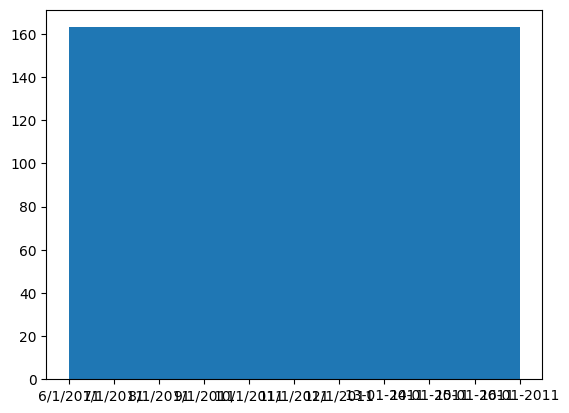

In [ ]:
plt.hist(vv['order_date'],bins=(5,15))
plt.show()

In [ ]:
data=vv[0:100]

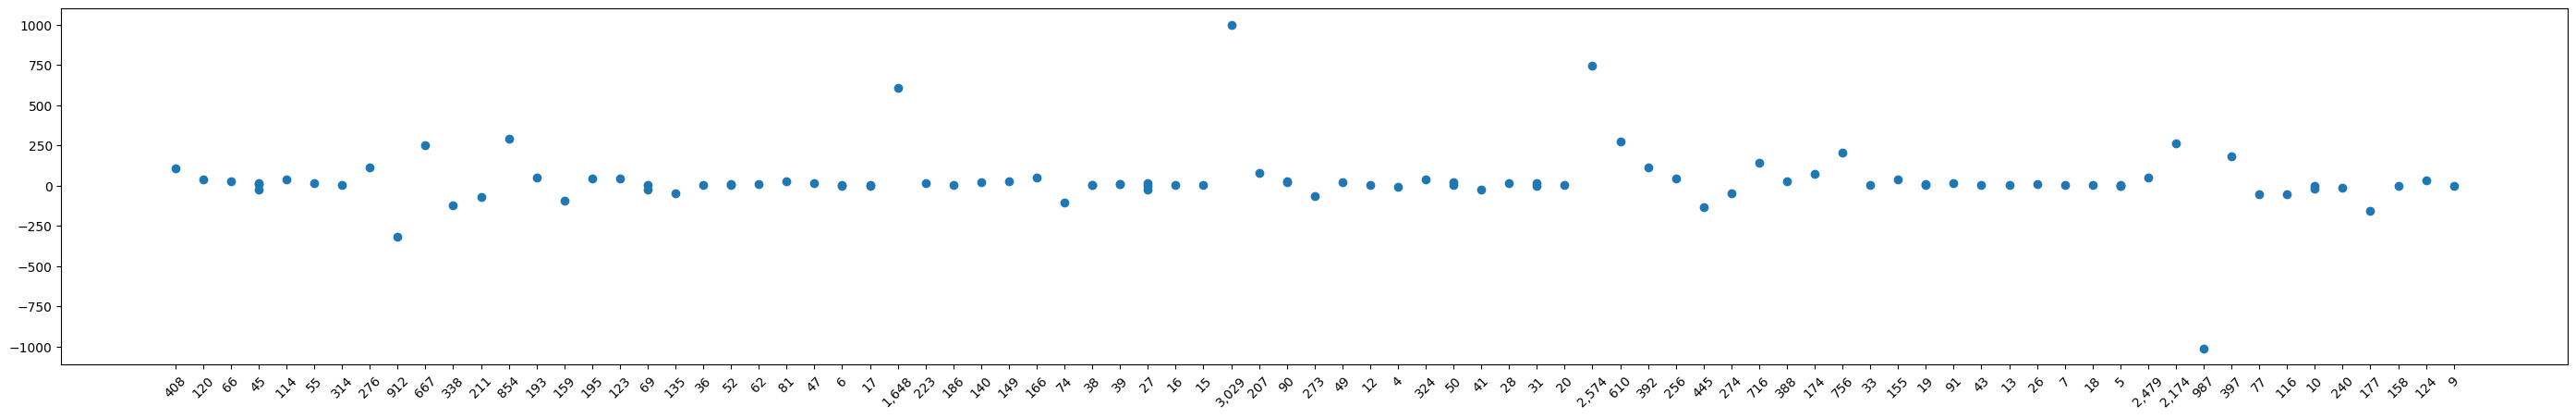

In [ ]:
plt.figure(figsize=(35,5))
plt.scatter(data['sales'],data['profit'])
plt.xticks(rotation=45)
plt.show()

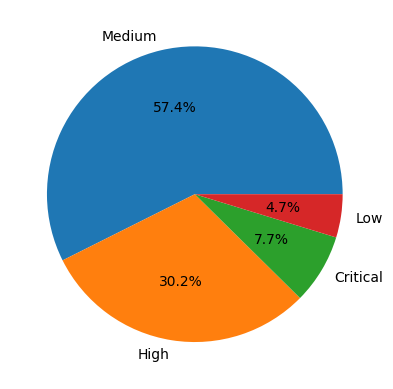

In [ ]:
priority_counts = vv['order_priority'].value_counts()
plt.pie(priority_counts, labels=priority_counts.index, autopct='%1.1f%%')
plt.show()

In [ ]:
import seaborn as sns

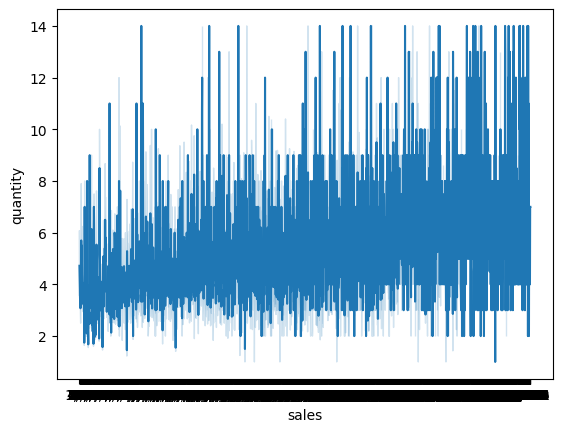

In [ ]:
sns.lineplot(x= 'sales', y='quantity', data=vv)
plt.show()

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "harvard-university/electoral-integrity",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



/tmp/ipython-input-2301100073.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


ValueError: Unsupported file extension: ''. Supported file extensions are: .csv, .tsv, .json, .jsonl, .xml, .parquet, .feather, .sqlite, .sqlite3, .db, .db3, .s3db, .dl3, .xls, .xlsx, .xlsm, .xlsb, .odf, .ods, .odt

In [ ]:
Print("First 5 records:", df.head())

In [ ]:
Print("First 5 records:", df.head())

In [ ]:
export KAGGLE_API_TOKEN=KGAT_d28db15ef0e98253fa78fda6bce75709

In [ ]:
from IPython.core.display import json
from google.colab import files
files.upload('kaggle.json')

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "robiulhasanjisan/university-student-performance-and-habits-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

In [ ]:
vr =pd.read_csv('/content/SuperStoreOrders 2.csv')

In [ ]:
vr

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01/01/11,06/01/11,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01/01/11,05/01/11,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01/01/11,05/01/11,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/14,04/01/15,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/14,05/01/15,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/14,02/01/15,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/14,06/01/15,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [ ]:
vr.shsape

(51290, 21)

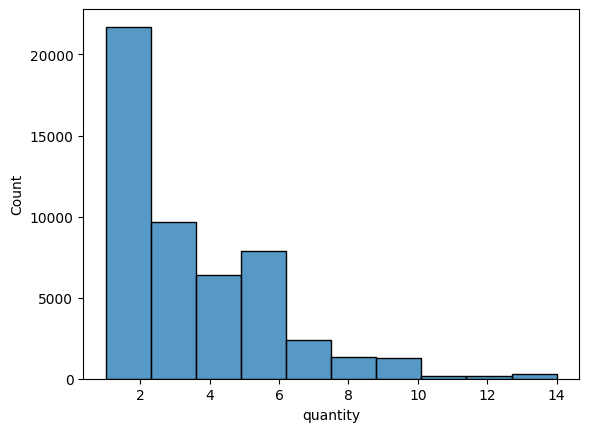

In [ ]:
sns.histplot(x ='quantity', data=vr, bins=10)
plt.show()

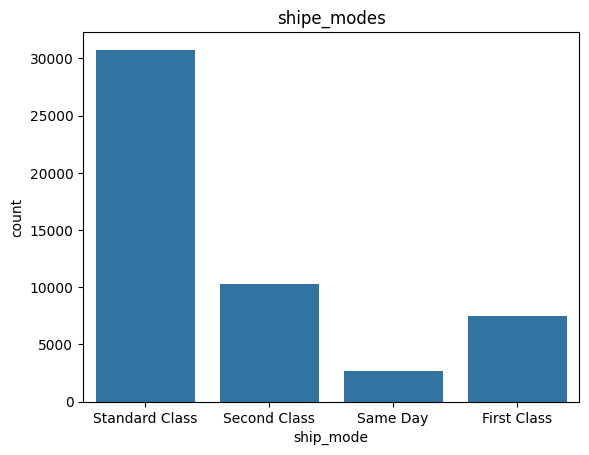

In [ ]:
sns.countplot(x='ship_mode', data=vr)
plt.title('shipe_modes')
plt.show()

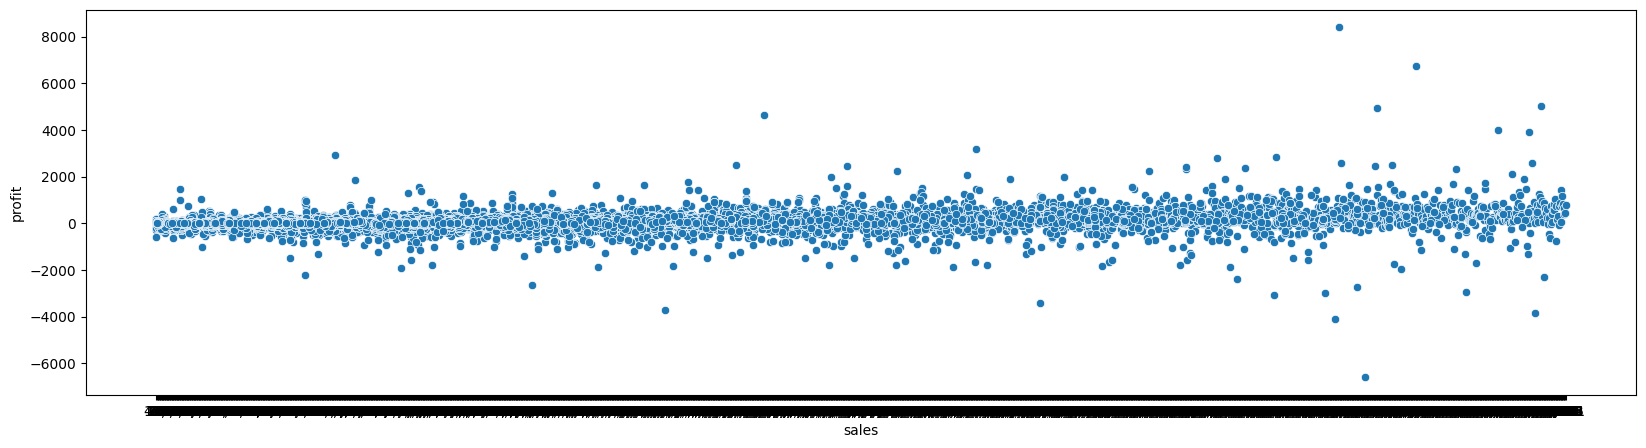

In [ ]:
plt.figure(figsize=(20,5))
sns.scatterplot(x='sales', y='profit', data=vr)

plt.show()

# EDA- Exploratry Data Analysis
steps-

1. Objective / Business analysis
2. import .library pandas
3. impor dataset
4. Ufderstand the dataset
5. C laen the dataseet
6. plot the char
7. find the insights
8. Summry

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vr

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01/01/11,06/01/11,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01/01/11,05/01/11,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01/01/11,05/01/11,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/14,04/01/15,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/14,05/01/15,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/14,02/01/15,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/14,06/01/15,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [ ]:
vr.shape

(51290, 21)

In [ ]:
vr.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01/01/11,06/01/11,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01/01/11,05/01/11,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01/01/11,05/01/11,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
vr.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [ ]:
vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

#Data clean

In [ ]:
vr.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
vr.dropna('')

In [ ]:
vr.duplicated().sum()

np.int64(0)

In [ ]:
sns.bar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vr =pd.read_excel('/content/Raw Mobile Sales Dataset.xlsx')

In [ ]:
vr

,Transaction ID,Day,month,Year,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
0,1,9,10,2021,Xiaomi,6.0,10174.70,Lalita Ahuja,38.0,Ludhiana,UPI,5.0,Redmi Note 10
1,2,9,10,2021,Vivo,6.0,10565.19,Sneha Sharma,37.0,Delhi,Credit Card,3.0,Vivo Y51
2,3,9,10,2021,Vivo,8.0,58527.58,Radha Srivastava,40.0,Mumbai,UPI,5.0,Vivo S1
3,4,10,10,2021,Xiaomi,5.0,25563.98,Bhavana Arora,21.0,Mumbai,Credit Card,4.0,Mi 11
4,5,10,10,2021,OnePlus,3.0,48168.02,Sneha Mehta,38.0,Gorakhpur,Cash,5.0,OnePlus 9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3830,3831,7,10,2024,OnePlus,9.0,43406.12,Kavita Bhatnagar,41.0,Mumbai,Cash,5.0,OnePlus 8T
3831,3832,8,10,2024,Xiaomi,8.0,34675.31,Vivek Sheth,25.0,Jodhpur,UPI,2.0,Redmi 9
3832,3833,8,10,2024,OnePlus,7.0,37620.23,Anita Desai,34.0,Vadodara,UPI,5.0,OnePlus 8T
3833,3834,8,10,2024,OnePlus,4.0,16961.04,Ayesha Rathod,51.0,Mumbai,Debit Card,5.0,OnePlus 8T


In [ ]:
vr.shape

(3835, 13)

In [ ]:

vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    3835 non-null   int64  
 1   Day               3835 non-null   int64  
 2   month             3835 non-null   int64  
 3   Year              3835 non-null   int64  
 4   Brand             3814 non-null   object 
 5   Units Sold        3814 non-null   float64
 6   Price Per Unit    3835 non-null   float64
 7   Customer Name     3835 non-null   object 
 8   Customer Age      3812 non-null   float64
 9   City              3807 non-null   object 
 10  Payment Method    3835 non-null   object 
 11  Customer Ratings  3804 non-null   float64
 12  Mobile Model      3835 non-null   object 
dtypes: float64(4), int64(4), object(5)
memory usage: 389.6+ KB


In [ ]:
vr.head()

,Transaction ID,Day,month,Year,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
0,1,9,10,2021,Xiaomi,6.0,10174.70,Lalita Ahuja,38.0,Ludhiana,UPI,5.0,Redmi Note 10
1,2,9,10,2021,Vivo,6.0,10565.19,Sneha Sharma,37.0,Delhi,Credit Card,3.0,Vivo Y51
2,3,9,10,2021,Vivo,8.0,58527.58,Radha Srivastava,40.0,Mumbai,UPI,5.0,Vivo S1
3,4,10,10,2021,Xiaomi,5.0,25563.98,Bhavana Arora,21.0,Mumbai,Credit Card,4.0,Mi 11
4,5,10,10,2021,OnePlus,3.0,48168.02,Sneha Mehta,38.0,Gorakhpur,Cash,5.0,OnePlus 9


In [ ]:
vr.isnull().sum()

,0
Transaction ID,0
Day,0
month,0
Year,0
Brand,0
Units Sold,0
Price Per Unit,0
Customer Name,0
Customer Age,0
City,0


In [ ]:
vr = vr.dropna(subset=['Brand'])

In [ ]:
vr= vr.dropna(subset=['Units Sold'])

In [ ]:
vr.dropna(inplace=True)

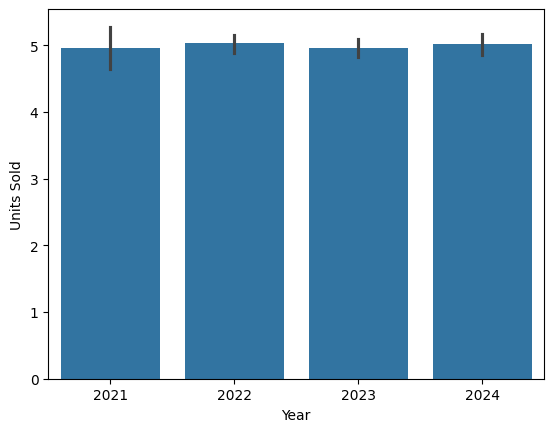

In [ ]:
# Find yje year wise sales
sns.barplot(x='Year', y='Units Sold', data=vr)
plt.show()

In [ ]:
vr['Price Per Unit'].sum()

np.float64(149333788.44)

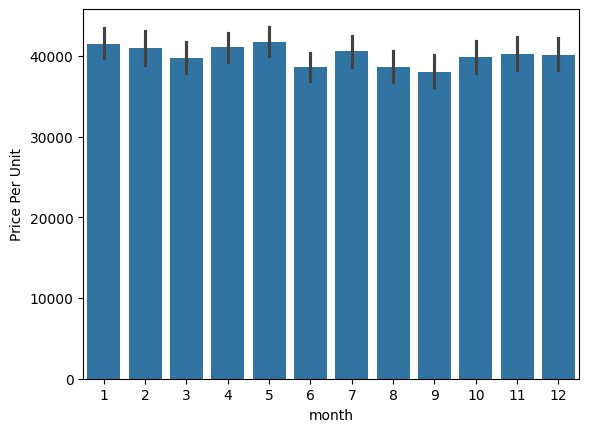

In [ ]:
# find the month wise total Amount
sns.barplot(x='month', y='Price Per Unit', data=vr)
plt.show()

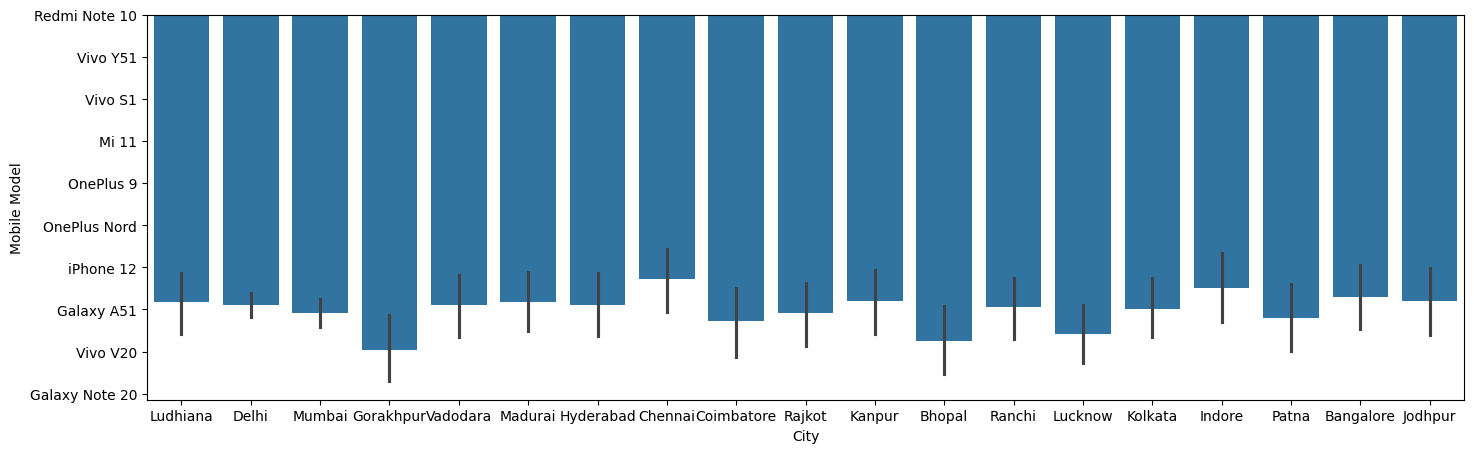

In [ ]:
# Find the cir=ty wisw Quantity
plt.figure(figsize=(17,5))
sns.barplot(x='City', y='Mobile Model', data=vr)
plt.show()

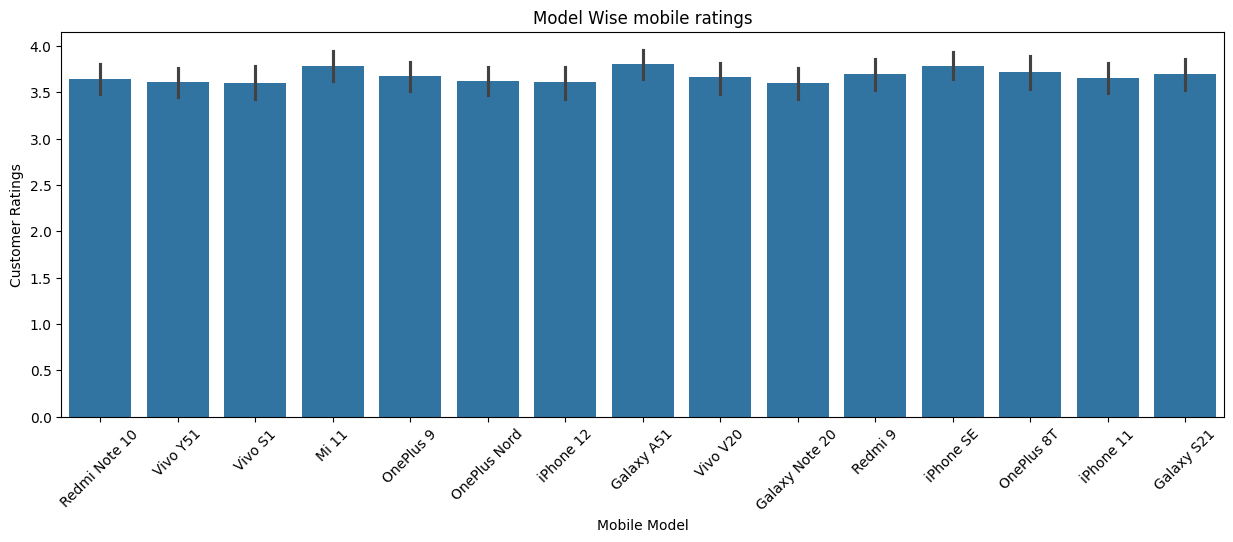

In [ ]:
# mobile modal wise customer ratings
plt.figure(figsize=(15,5))
sns.barplot(x='Mobile Model', y='Customer Ratings', data=vr)
plt.xticks(rotation=45)
plt.title('Model Wise mobile ratings')
plt.show()

# EDA

In [ ]:
# add library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vr=pd.read_csv('/content/ds_salaries.csv')



In [ ]:
vr

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [ ]:

vr.shape

(607, 12)

In [ ]:
vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [ ]:
vr.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
vr.isnull().sum()

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [ ]:
vr.duplicated().sum()

np.int64(0)

# CHARTS

In [ ]:
C

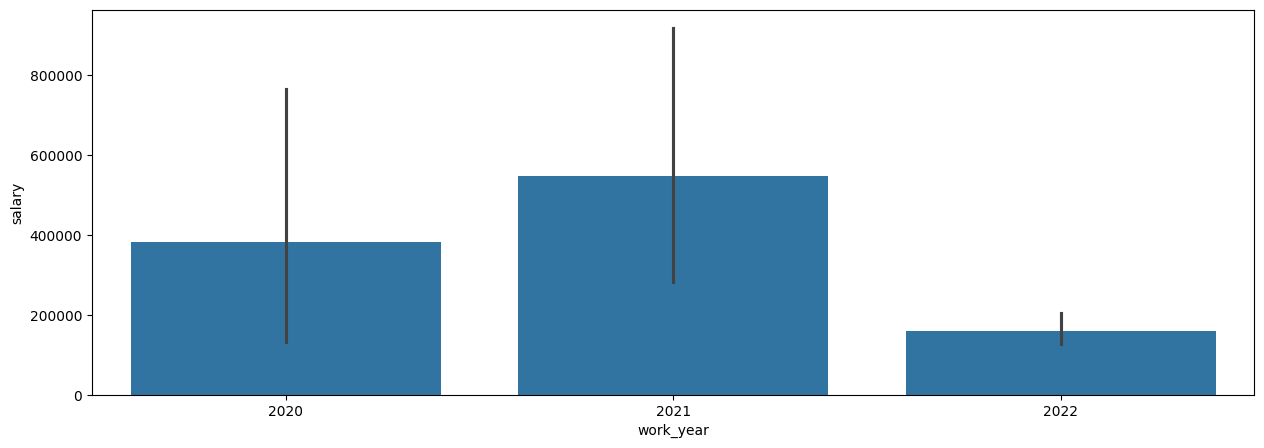

In [ ]:
# year wise salary
plt.figure(figsize=(15,5))
sns.barplot(x='work_year', y='salary', data=vr)
plt.show()

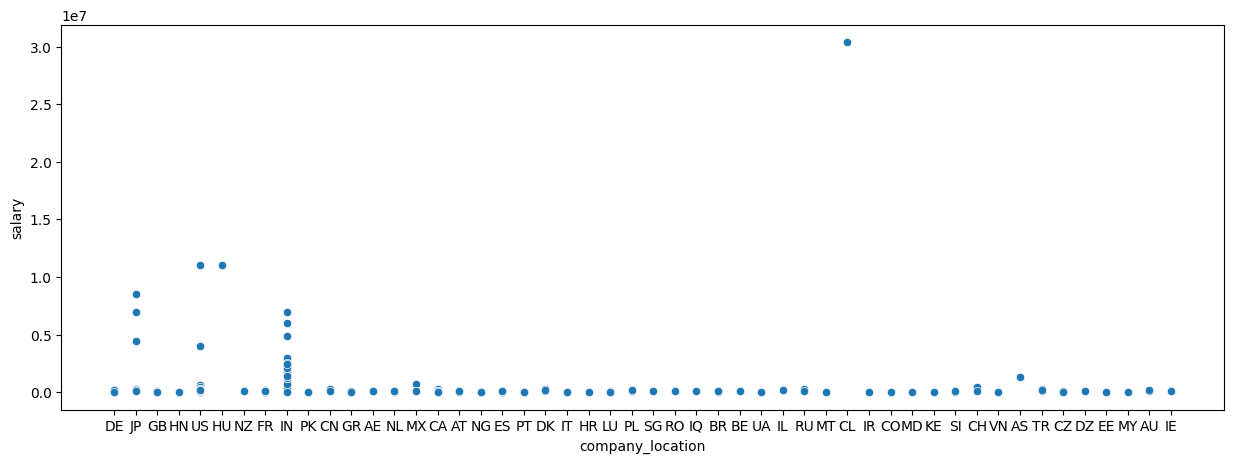

In [ ]:
# job title whose salry
plt.figure(figsize=(15,5))
sns.scatterplot(x='job_title', y='salary', data=vr)
plt.show()

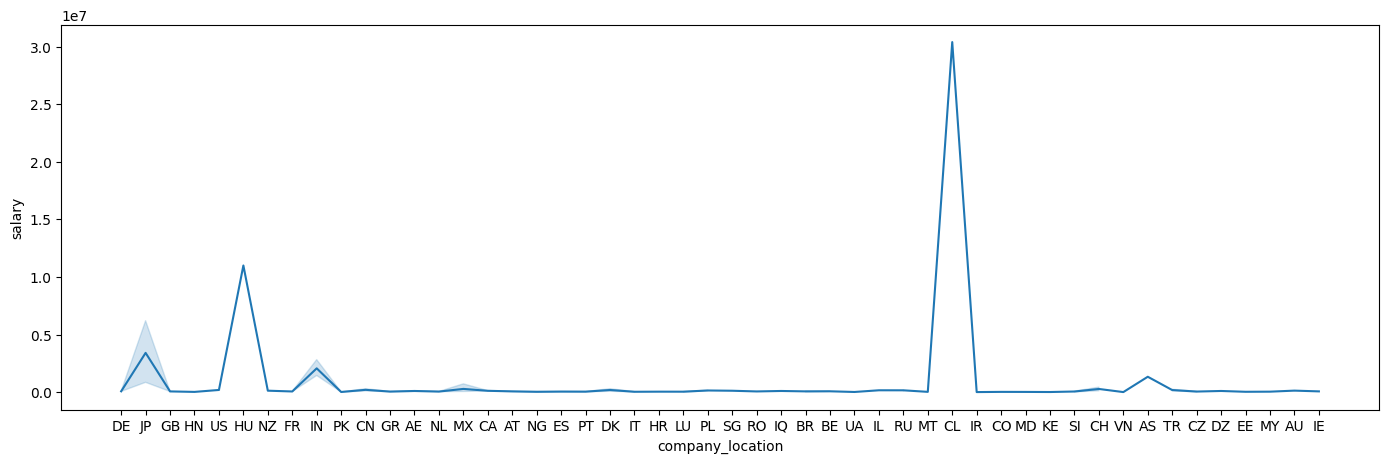

In [ ]:
plt.figure(figsize=(17,5))
#sns.barplot(x='experience_level', y='salary', data=vr
sns.lineplot(x ='company_location', y='salary', data=vr)
plt.show()

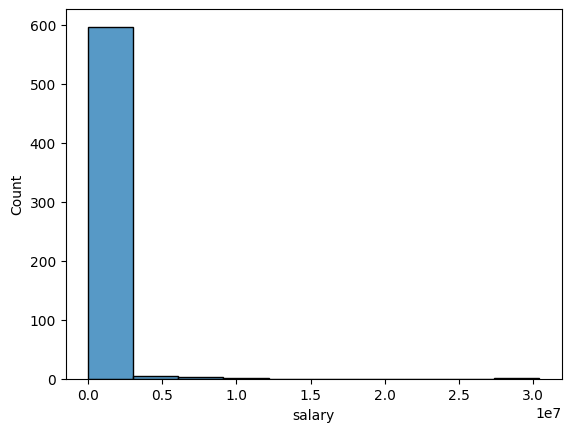

In [ ]:
sns.histplot(x='salary', data=vr, bins=10)
plt.show()

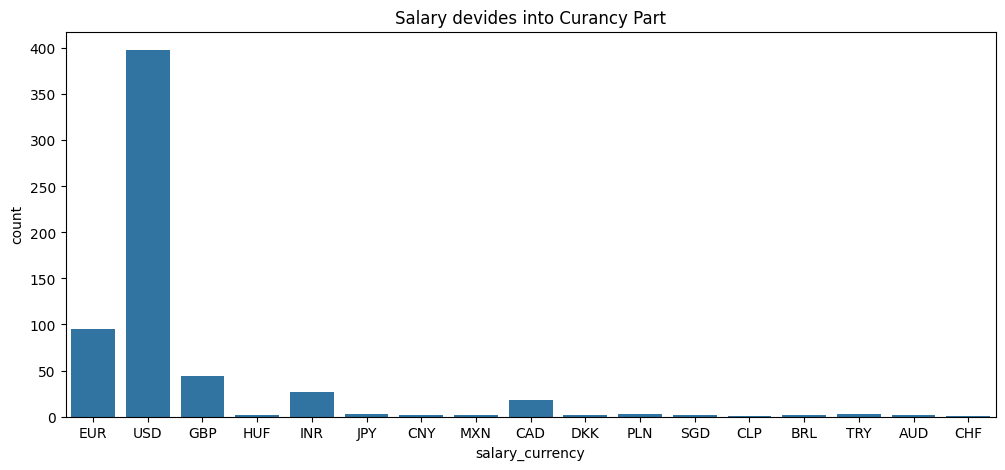

In [ ]:
# whose amount recive salary
plt.figure(figsize=(12,5))
sns.countplot(x='salary_currency', data=vr)
plt.title('Salary devides into Curancy Part')
plt.show()

In [ ]:
sns.heatmap(x='')

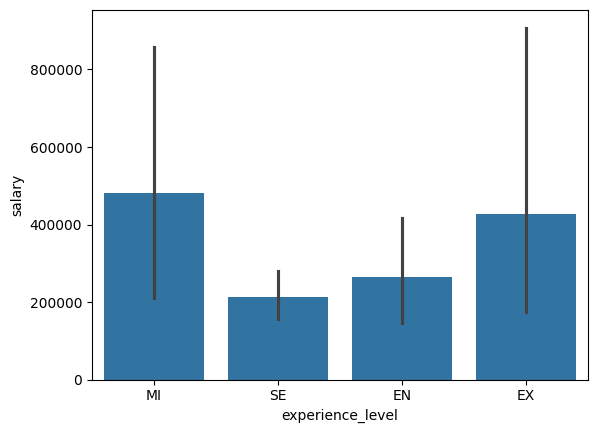

In [ ]:
# 3. exprience leval salary
sns.barplot(x='experience_level', y='salary', data=vr)
plt.show()

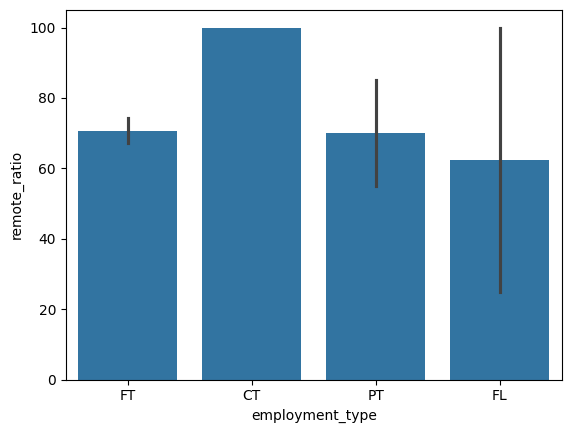

In [ ]:
# 4. haow manu employment most remote ratio
#sns.scatterplot(x='employment_type', y='remote_ratio', data=vr)
sns.barplot(x='employment_type', y='remote_ratio', data=vr)
plt.show()

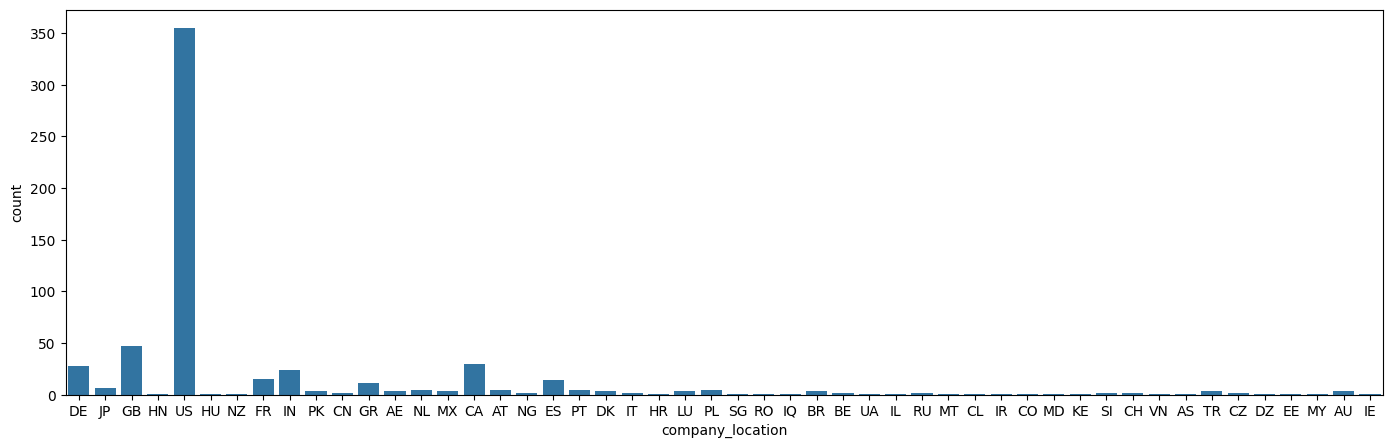

In [ ]:
# 5.wich location mostly is whose pratable
plt.figure(figsize=(17,5))
sns.countplot(x='company_location', data=vr)
plt.show()

In [ ]:
# 6.mostly employeess work in with compnies
# small, medium,or large


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vr=pd.read_csv('/content/hotel_bookings.csv')

In [ ]:
vr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
vr.shape

(119390, 32)

In [ ]:
vr.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
vr.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
vr.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


a

# DubliCatges Value

```
`# This is formatted as code`
```



In [ ]:
vr.duplicated().sum()

np.int64(0)

In [ ]:
vr = vr.drop_duplicates().copy()
print(vr.shape)

(189, 32)


In [ ]:

vr.dropna(inplace=True)
#print(vr.shape)

/tmp/ipython-input-1211/1061585410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vr.dropna(inplace=True)


In [ ]:
vr.dropna(subset=['country'], inplace=True)

/tmp/ipython-input-1211/2201821158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vr.dropna(subset=['country'], inplace=True)


EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
st=pd.read_csv('/content/student_dropout_dataset_v3.csv')

In [ ]:
st

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


Understand the data

In [ ]:
st.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [ ]:
st.shape

(10000, 19)

In [ ]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [ ]:
st.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [ ]:
st.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
st.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [ ]:
st.dropna(inplace=True)

In [ ]:
st.duplicated().sum()

np.int64(0)

# Create the charts

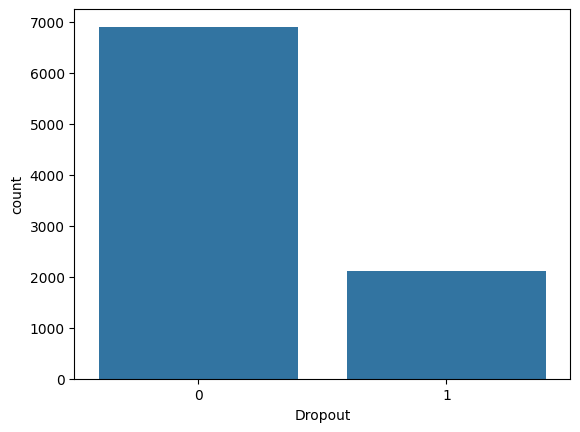

In [ ]:
# wich is sumothing dropout student
sns.countplot(x='Dropout',data=st)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [3]:
vr =pd.read_csv('/content/SuperStoreOrders 2.csv')

In [4]:
vr

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01/01/11,06/01/11,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01/01/11,05/01/11,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01/01/11,05/01/11,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01/01/11,08/01/11,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/14,04/01/15,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/14,05/01/15,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/14,02/01/15,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/14,06/01/15,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
